<a href="https://colab.research.google.com/github/nurgul162/Codesstars.team/blob/main/Yaban_Hayati_YOLOv11_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install ultralytics roboflow -q

import os, cv2, glob, shutil, random, yaml
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from collections import Counter
from ultralytics import YOLO

print('✅ Kütüphaneler yüklendi.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 85.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Kütüphaneler yüklendi.


In [5]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Cihaz : {device.upper()}')
if device == 'cuda':
    print(f'GPU   : {torch.cuda.get_device_name(0)}')
    print(f'VRAM  : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('⚠️  GPU yok! Çalışma Zamanı → T4 GPU seçin.')

Cihaz : CUDA
GPU   : Tesla T4
VRAM  : 15.6 GB


In [6]:
!pip install roboflow

from roboflow import Roboflow

rf      = Roboflow(api_key='4H8N8MhrGw4nEd9UxEhN')
project = rf.workspace('animals-sxz9n').project('animal-detection-jvsw5')
version = project.version(1)
dataset = version.download('yolov11')

DATASET_PATH = dataset.location
print(f'\n✅ Dataset indirildi: {DATASET_PATH}')

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Animal-Detection--1 in yolov11:: 100%|██████████| 10810/10810 [00:01<00:00, 6599.25it/s]


✅ Dataset indirildi: /content/Animal-Detection--1


In [7]:
# data.yaml dosyasını bul ve oku
yaml_path = os.path.join(DATASET_PATH, 'data.yaml')

with open(yaml_path) as f:
    data_cfg = yaml.safe_load(f)

# Colab yollarına göre düzelt
data_cfg['path'] = DATASET_PATH
with open(yaml_path, 'w') as f:
    yaml.dump(data_cfg, f)

class_names = data_cfg.get('names', [])
if isinstance(class_names, dict):
    class_names = list(class_names.values())
nc = len(class_names)

print(f'Sınıf sayısı : {nc}')
print(f'İlk 15 sınıf : {class_names[:15]}')

for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(DATASET_PATH, split, 'images')
    if os.path.exists(img_dir):
        imgs = glob.glob(img_dir+'/*.jpg') + glob.glob(img_dir+'/*.png')
        print(f'{split:6s}: {len(imgs)} görüntü')

Sınıf sayısı : 91
İlk 15 sınıf : ['antelope', 'badger', 'bat', 'bear', 'bee', 'beetle', 'bison', 'boar', 'butterfly', 'cat', 'caterpillar', 'chimpanzee', 'cockroach', 'cow', 'coyote']
train : 3779 görüntü
valid : 1080 görüntü
test  : 540 görüntü


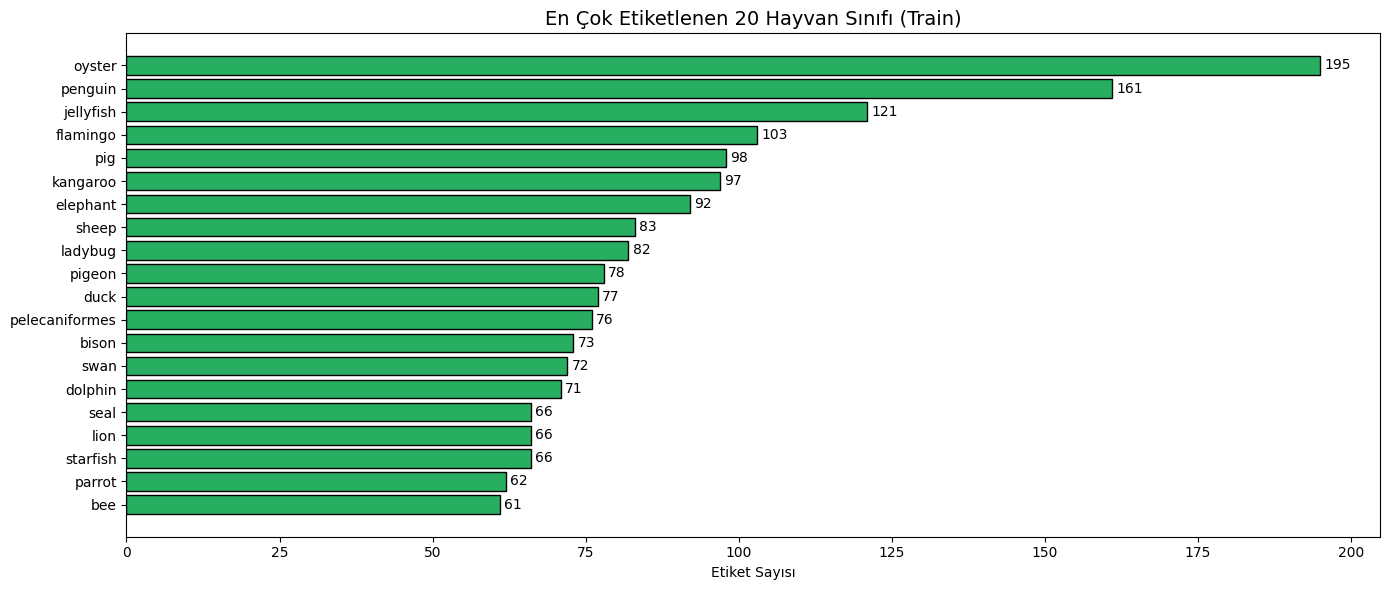

Toplam etiket: 5188


In [8]:
# Sınıf dağılımı
label_dir = os.path.join(DATASET_PATH, 'train', 'labels')
class_counts = Counter()

for lf in glob.glob(label_dir + '/*.txt'):
    with open(lf) as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                class_counts[int(parts[0])] += 1

top20 = class_counts.most_common(20)
labels_top = [class_names[i] if i < len(class_names) else str(i) for i,_ in top20]
counts_top = [c for _,c in top20]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(labels_top[::-1], counts_top[::-1], color='#27ae60', edgecolor='black')
ax.bar_label(bars, padding=3)
ax.set_title('En Çok Etiketlenen 20 Hayvan Sınıfı (Train)', fontsize=14)
ax.set_xlabel('Etiket Sayısı')
plt.tight_layout()
plt.show()
print(f'Toplam etiket: {sum(class_counts.values())}')

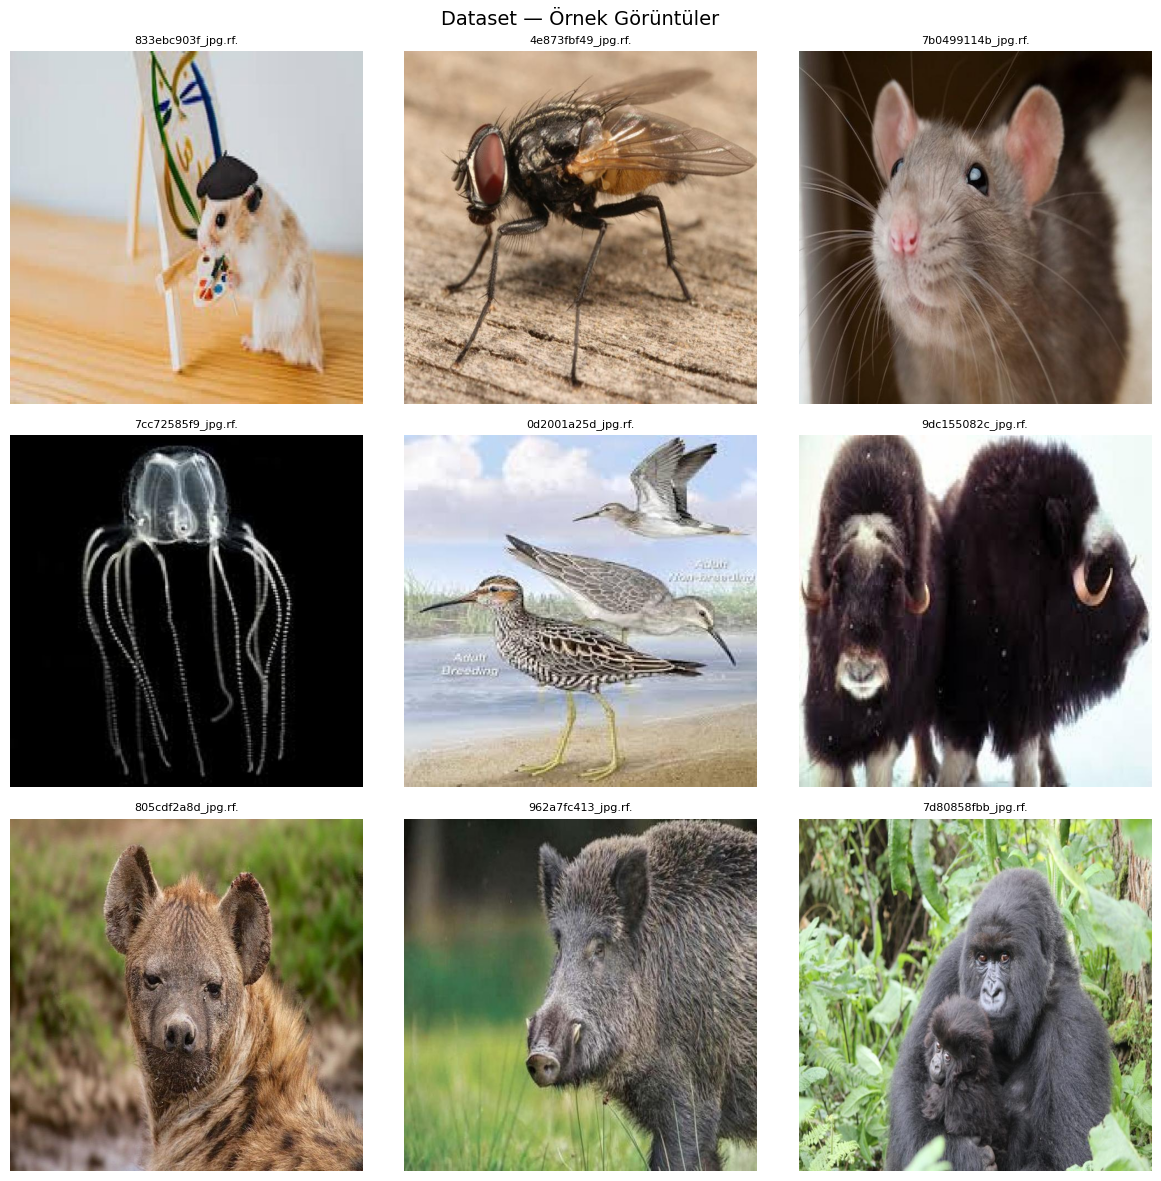

In [9]:
# Örnek görüntüler
img_dir  = os.path.join(DATASET_PATH, 'train', 'images')
all_imgs = glob.glob(img_dir+'/*.jpg') + glob.glob(img_dir+'/*.png')
samples  = random.sample(all_imgs, min(9, len(all_imgs)))

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for ax, p in zip(axes.flatten(), samples):
    ax.imshow(PILImage.open(p))
    ax.set_title(os.path.basename(p)[:18], fontsize=8)
    ax.axis('off')
plt.suptitle('Dataset — Örnek Görüntüler', fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
MODEL_SIZE = 'yolo11m'
EPOCHS     = 35
BATCH      = 16
IMG_SIZE   = 640
PROJECT    = '/content/runs/wildlife'
RUN_NAME   = 'yolo11m_animal92'

model = YOLO(f'{MODEL_SIZE}.pt')
print(f'✅ {MODEL_SIZE}.pt yüklendi, eğitim başlıyor...')

results = model.train(
    data     = yaml_path,
    epochs   = EPOCHS,
    imgsz    = IMG_SIZE,
    batch    = BATCH,
    device   = device,
    project  = PROJECT,
    name     = RUN_NAME,
    patience = 15,
    save     = True,
    plots    = True,
    lr0      = 0.01,
    augment  = True,
    mosaic   = 1.0,
    flipud   = 0.5,
    fliplr      = 0.5,
    degrees  = 10.0
)

BEST_MODEL = f'{PROJECT}/{RUN_NAME}/weights/best.pt'
print(f'\n🎉 Eğitim tamamlandı!')
print(f'📁 En iyi model: {BEST_MODEL}')

✅ yolo11m.pt yüklendi, eğitim başlıyor...
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Animal-Detection--1/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11m_animal92, nbs=64, nms=False, opset=None, optim

📊 results.png


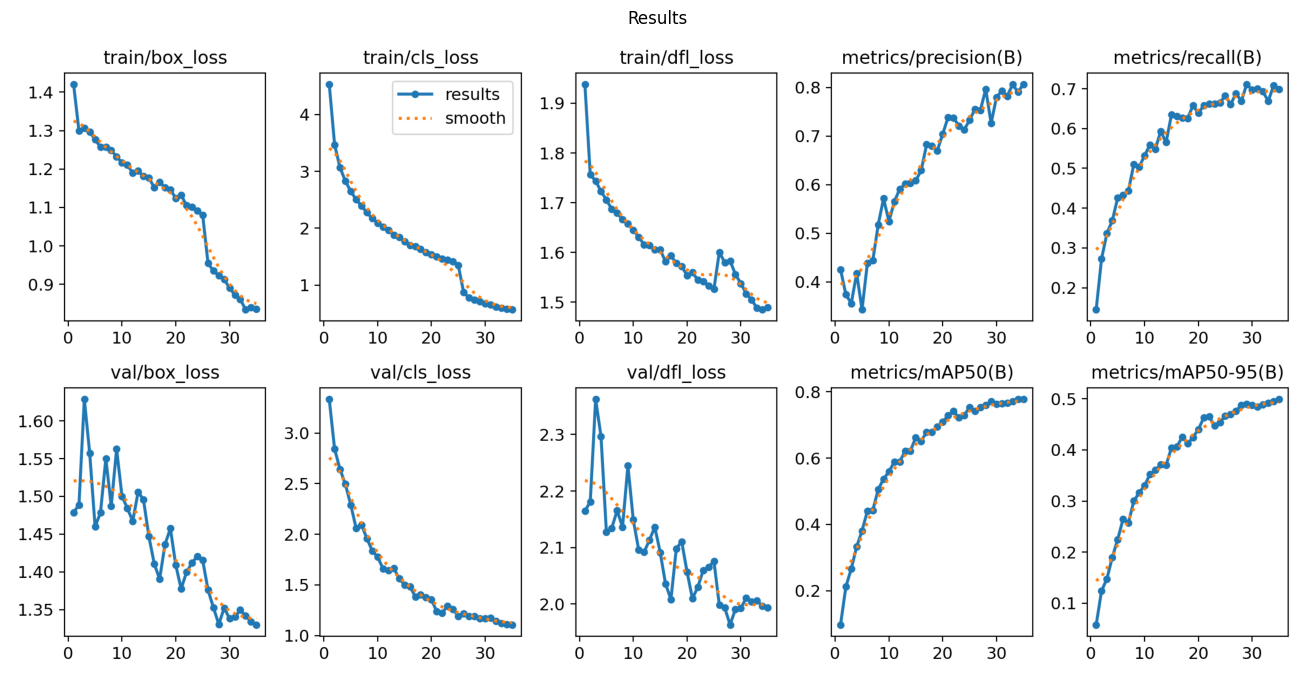

📊 confusion_matrix.png


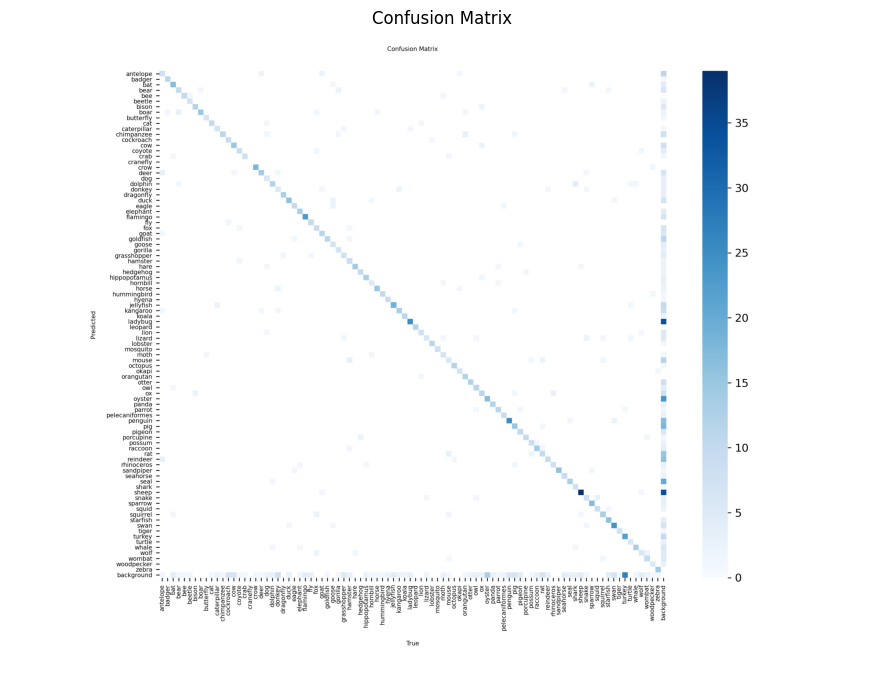

In [12]:
run_dir = f'{PROJECT}/{RUN_NAME}'

for pf in ['results.png', 'confusion_matrix.png', 'PR_curve.png']:
    fp = os.path.join(run_dir, pf)
    if os.path.exists(fp):
        print(f'📊 {pf}')
        plt.figure(figsize=(14, 7))
        plt.imshow(PILImage.open(fp))
        plt.axis('off')
        plt.title(pf.replace('.png','').replace('_',' ').title())
        plt.tight_layout()
        plt.show()

In [13]:
best_model   = YOLO(BEST_MODEL)
val_results  = best_model.val(data=yaml_path, imgsz=IMG_SIZE, device=device)

print('\n📈 Validation Sonuçları:')
print(f'  mAP@50    : {val_results.box.map50:.4f}')
print(f'  mAP@50-95 : {val_results.box.map:.4f}')
print(f'  Precision : {val_results.box.mp:.4f}')
print(f'  Recall    : {val_results.box.mr:.4f}')

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,100,193 parameters, 0 gradients, 68.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2047.2±623.9 MB/s, size: 69.0 KB)
val: Scanning /content/Animal-Detection--1/valid/labels.cache... 1080 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1080/1080 323.6Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 4, len(boxes) = 1437. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 68/68 1.8it/s 36.8s
                   all       1080       1437      0.804      0.701      0.778      0.499
              antelope         14         17       0.55      0.529      0.681      0.469
                badger 

In [14]:
def detect_image(image_path, conf=0.35, show=True):
    m       = YOLO(BEST_MODEL)
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f'❌ Görüntü okunamadı: {image_path}'); return

    results   = m(img_bgr, conf=conf, verbose=False)
    annotated = results[0].plot()

    detected = Counter()
    for box in results[0].boxes:
        detected[m.names[int(box.cls[0])]] += 1

    print(f'📊 Toplam: {sum(detected.values())} hayvan')
    for sp, n in detected.most_common():
        print(f'   • {sp}: {n}')

    if show:
        rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(13, 8))
        plt.imshow(rgb); plt.axis('off')
        plt.title(f'Tespit: {sum(detected.values())} hayvan', fontsize=14)
        plt.tight_layout(); plt.show()
    return annotated

print('✅ Fonksiyon hazır.')

✅ Fonksiyon hazır.


📊 Toplam: 1 hayvan
   • fox: 1


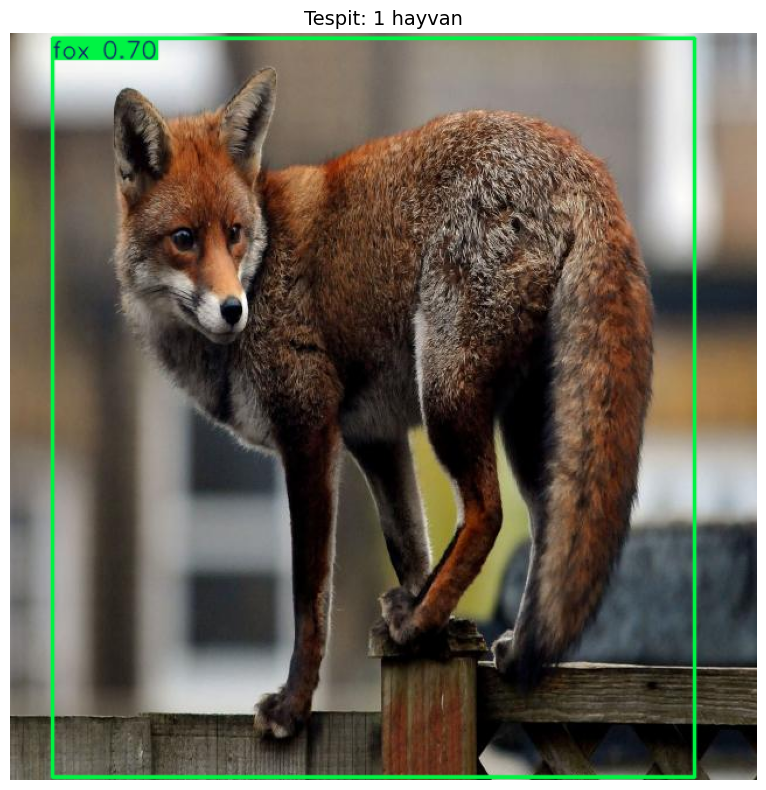

In [15]:
# Validation setinden rastgele test
val_imgs = glob.glob(os.path.join(DATASET_PATH,'valid','images','*.jpg'))
val_imgs += glob.glob(os.path.join(DATASET_PATH,'valid','images','*.png'))
if val_imgs:
    detect_image(random.choice(val_imgs), conf=0.35)
else:
    print('Val klasörü bulunamadı.')

Görüntü seçin (.jpg / .png):


Saving images (1).jpg to images (1).jpg
📊 Toplam: 1 hayvan
   • tiger: 1


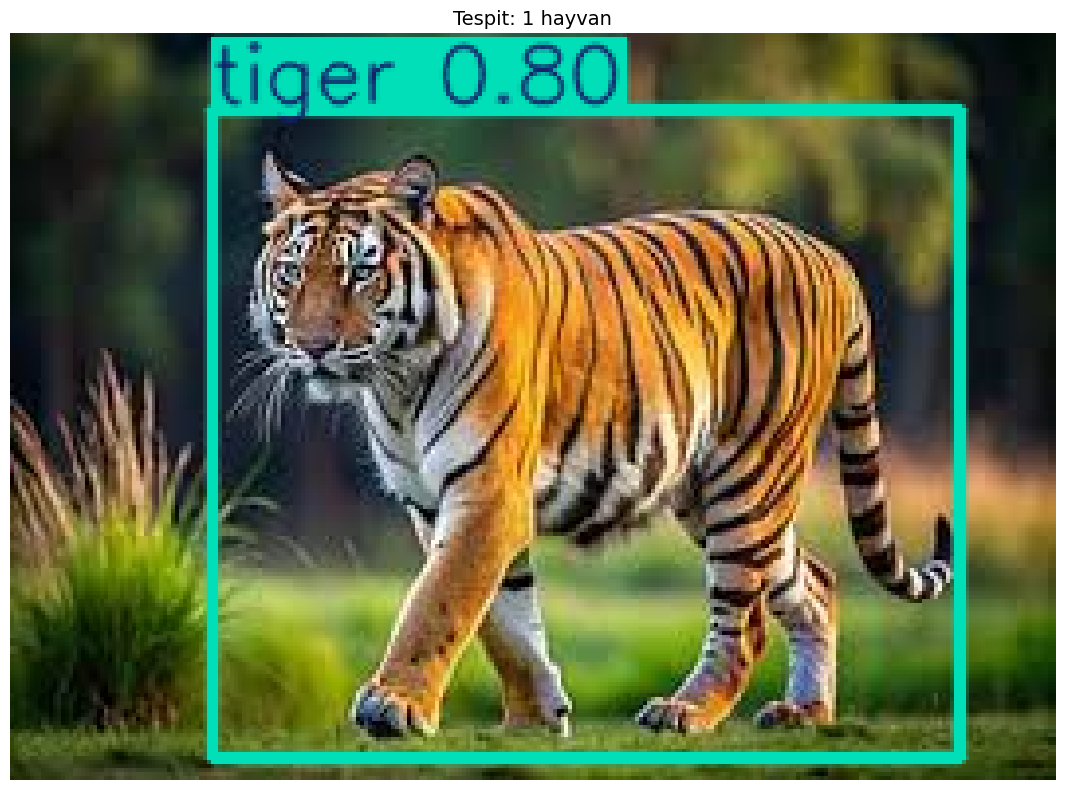

In [17]:
# Kendi görüntünüzü yükleyin
from google.colab import files
print('Görüntü seçin (.jpg / .png):')
uploaded = files.upload()
for fname in uploaded:
    path = f'/content/{fname}'
    open(path,'wb').write(uploaded[fname])
    detect_image(path, conf=0.35)

In [18]:
def batch_detect(folder, conf=0.35, max_show=6):
    m = YOLO(BEST_MODEL)
    paths = []
    for ext in ('*.jpg','*.jpeg','*.png'):
        paths.extend(glob.glob(os.path.join(folder, ext)))
    if not paths:
        print('Görüntü bulunamadı.'); return
    print(f'{len(paths)} görüntü işleniyor...')
    total_sp = Counter()
    annotated_list = []
    for p in paths:
        img = cv2.imread(p)
        res = m(img, conf=conf, verbose=False)
        annotated_list.append(res[0].plot())
        for box in res[0].boxes:
            total_sp[m.names[int(box.cls[0])]] += 1

    # Örnek görseller
    n = min(max_show, len(annotated_list))
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1: axes = [axes]
    for ax, ann in zip(axes, annotated_list[:n]):
        ax.imshow(cv2.cvtColor(ann, cv2.COLOR_BGR2RGB)); ax.axis('off')
    plt.suptitle('Tespit Edilen Görüntüler'); plt.tight_layout(); plt.show()

    # İstatistik grafiği
    if total_sp:
        top = total_sp.most_common(15)
        fig, ax = plt.subplots(figsize=(12, 5))
        bars = ax.bar([x[0] for x in top],[x[1] for x in top],
                      color='#2ecc71', edgecolor='black')
        ax.bar_label(bars)
        ax.set_title('Tespit Edilen Hayvan Türleri', fontsize=13)
        ax.set_xlabel('Tür'); ax.set_ylabel('Adet')
        plt.xticks(rotation=35, ha='right')
        plt.tight_layout(); plt.show()
    return total_sp

# Kullanım: batch_detect('/content/test_images')
print('✅ Batch fonksiyonu hazır.')

✅ Batch fonksiyonu hazır.


In [21]:
# Değişken tanımlamaları
PROJECT   = '/content/runs/wildlife'
RUN_NAME  = 'yolo11m_animal92'
RUN_DIR   = f'{PROJECT}/{RUN_NAME}'

BEST_MODEL  = f'{RUN_DIR}/weights/best.pt'
RESULTS_CSV = f'{RUN_DIR}/results.csv'

print(f'✅ Değişkenler tanımlandı.')
print(f'   Model yolu : {BEST_MODEL}')
print(f'   Run dizini : {RUN_DIR}')

✅ Değişkenler tanımlandı.
   Model yolu : /content/runs/wildlife/yolo11m_animal92/weights/best.pt
   Run dizini : /content/runs/wildlife/yolo11m_animal92


In [22]:
import yaml
from collections import Counter

# data.yaml oku
with open(f'{DATASET_PATH}/data.yaml', 'r') as f:
    data_cfg = yaml.safe_load(f)

CLASS_NAMES = data_cfg['names']
print(f'Toplam sınıf sayısı : {len(CLASS_NAMES)}')
print(f'Sınıflar : {CLASS_NAMES}')

Toplam sınıf sayısı : 91
Sınıflar : ['antelope', 'badger', 'bat', 'bear', 'bee', 'beetle', 'bison', 'boar', 'butterfly', 'cat', 'caterpillar', 'chimpanzee', 'cockroach', 'cow', 'coyote', 'crab', 'cranefly', 'crow', 'deer', 'dog', 'dolphin', 'donkey', 'dragonfly', 'duck', 'eagle', 'elephant', 'flamingo', 'fly', 'fox', 'goat', 'goldfish', 'goose', 'gorilla', 'grasshopper', 'hamster', 'hare', 'hedgehog', 'hippopotamus', 'hornbill', 'horse', 'hummingbird', 'hyena', 'jellyfish', 'kangaroo', 'koala', 'ladybug', 'leopard', 'lion', 'lizard', 'lobster', 'mosquito', 'moth', 'mouse', 'octopus', 'okapi', 'orangutan', 'otter', 'owl', 'ox', 'oyster', 'panda', 'parrot', 'pelecaniformes', 'penguin', 'pig', 'pigeon', 'porcupine', 'possum', 'raccoon', 'rat', 'reindeer', 'rhinoceros', 'sandpiper', 'seahorse', 'seal', 'shark', 'sheep', 'snake', 'sparrow', 'squid', 'squirrel', 'starfish', 'swan', 'tiger', 'turkey', 'turtle', 'whale', 'wolf', 'wombat', 'woodpecker', 'zebra']


In [23]:
# Train / Val / Test görüntü & etiket sayıları
splits = {'train': 'train', 'val': 'valid', 'test': 'test'}

for split_name, split_folder in splits.items():
    img_dir = f'{DATASET_PATH}/{split_folder}/images'
    lbl_dir = f'{DATASET_PATH}/{split_folder}/labels'
    if not os.path.exists(img_dir):
        continue
    imgs = glob.glob(f'{img_dir}/*.jpg') + glob.glob(f'{img_dir}/*.png')
    lbls = glob.glob(f'{lbl_dir}/*.txt')
    print(f'{split_name:<8} → {len(imgs):>4} görüntü  |  {len(lbls):>4} etiket')

train    → 3779 görüntü  |  3779 etiket
val      → 1080 görüntü  |  1080 etiket
test     →  540 görüntü  |   540 etiket


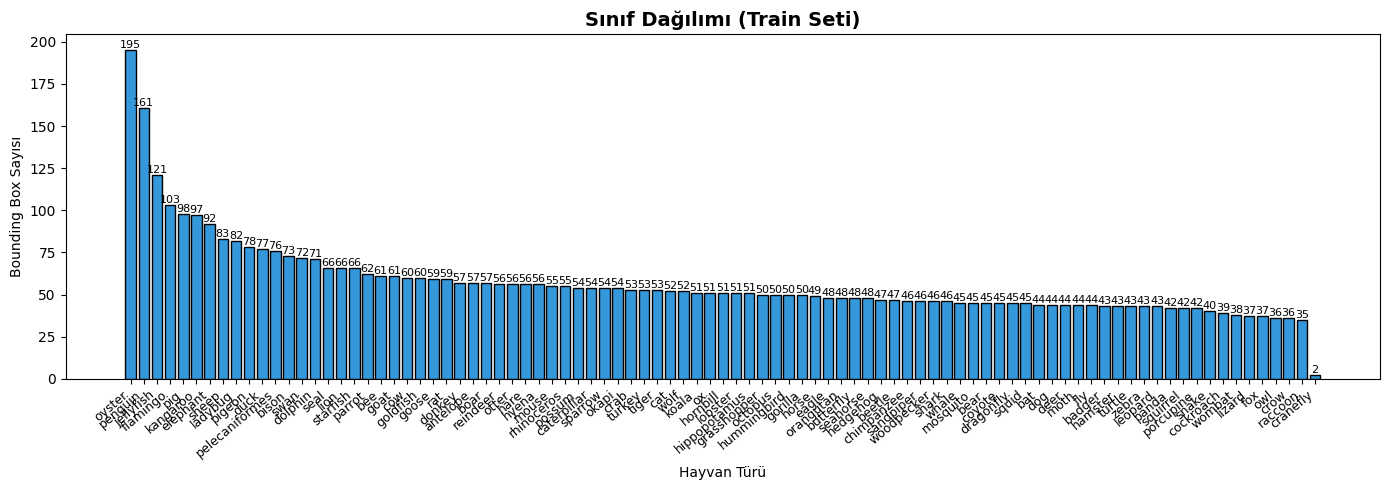


En fazla : oyster → 195
En az    : cranefly → 2
Oran     : 97.5x  ⚠️ Dengesiz!


In [30]:
# Sınıf dağılımı — train seti
label_dir = f'{DATASET_PATH}/train/labels'
class_counts = Counter()

for lbl_path in glob.glob(f'{label_dir}/*.txt'):
    with open(lbl_path) as f:
        for line in f:
            cls_id = int(line.strip().split()[0])
            class_counts[cls_id] += 1

# Grafik
sorted_counts = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
labels  = [CLASS_NAMES[i] for i, _ in sorted_counts]
counts  = [c for _, c in sorted_counts]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(labels, counts, color='#3498db', edgecolor='black')
ax.bar_label(bars, fontsize=8)
ax.set_title('Sınıf Dağılımı (Train Seti)', fontsize=14, fontweight='bold')
ax.set_xlabel('Hayvan Türü')
ax.set_ylabel('Bounding Box Sayısı')
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

# Dengesizlik uyarısı
max_c, min_c = max(counts), min(counts)
print(f'\nEn fazla : {labels[counts.index(max_c)]} → {max_c}')
print(f'En az    : {labels[counts.index(min_c)]} → {min_c}')
print(f'Oran     : {max_c/min_c:.1f}x  {"⚠️ Dengesiz!" if max_c/min_c > 5 else "✅ Dengeli"}')

In [31]:
from google.colab import files

if os.path.exists(BEST_MODEL):
    files.download(BEST_MODEL)
    print(f'✅ Model indiriliyor: {BEST_MODEL}')
else:
    print('⚠️ Eğitim henüz tamamlanmadı.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Model indiriliyor: /content/runs/wildlife/yolo11m_animal92/weights/best.pt


In [33]:
# Google Drive'a kaydet
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/YabanHayati_YOLOv11'
os.makedirs(SAVE_DIR, exist_ok=True)

if os.path.exists(BEST_MODEL):
    shutil.copy(BEST_MODEL, f'{SAVE_DIR}/best_model.pt')
    for pf in ['results.png','confusion_matrix.png','PR_curve.png']:
        fp = f'{PROJECT}/{RUN_NAME}/{pf}'
        if os.path.exists(fp):
            shutil.copy(fp, f'{SAVE_DIR}/{pf}')
    print(f'✅ Drive\'a kaydedildi: {SAVE_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive'a kaydedildi: /content/drive/MyDrive/YabanHayati_YOLOv11
